# Aufgabe 1

Bei der ersten Aufgabe sollten wir das Beugungsbild vom Einzelspalt messen. Mithilfe des Beugungsbildes können wir dann die Spaltbreite bestimmen und mit den echten Werten vergleichen. Wir haben 4 Messungen gemacht mit verschiedenen Spaltbreiten: 0,2mm; 0,4mm; 0,8mm und 1,6mm. Wir nutzen zwei verfahren für die bestimmung der Spaltbreite, zum einen über den Abstand vom Hauptmaxima zum Minimum erster Ordnung und zum anderen mithilfe der Fouriertransformation.

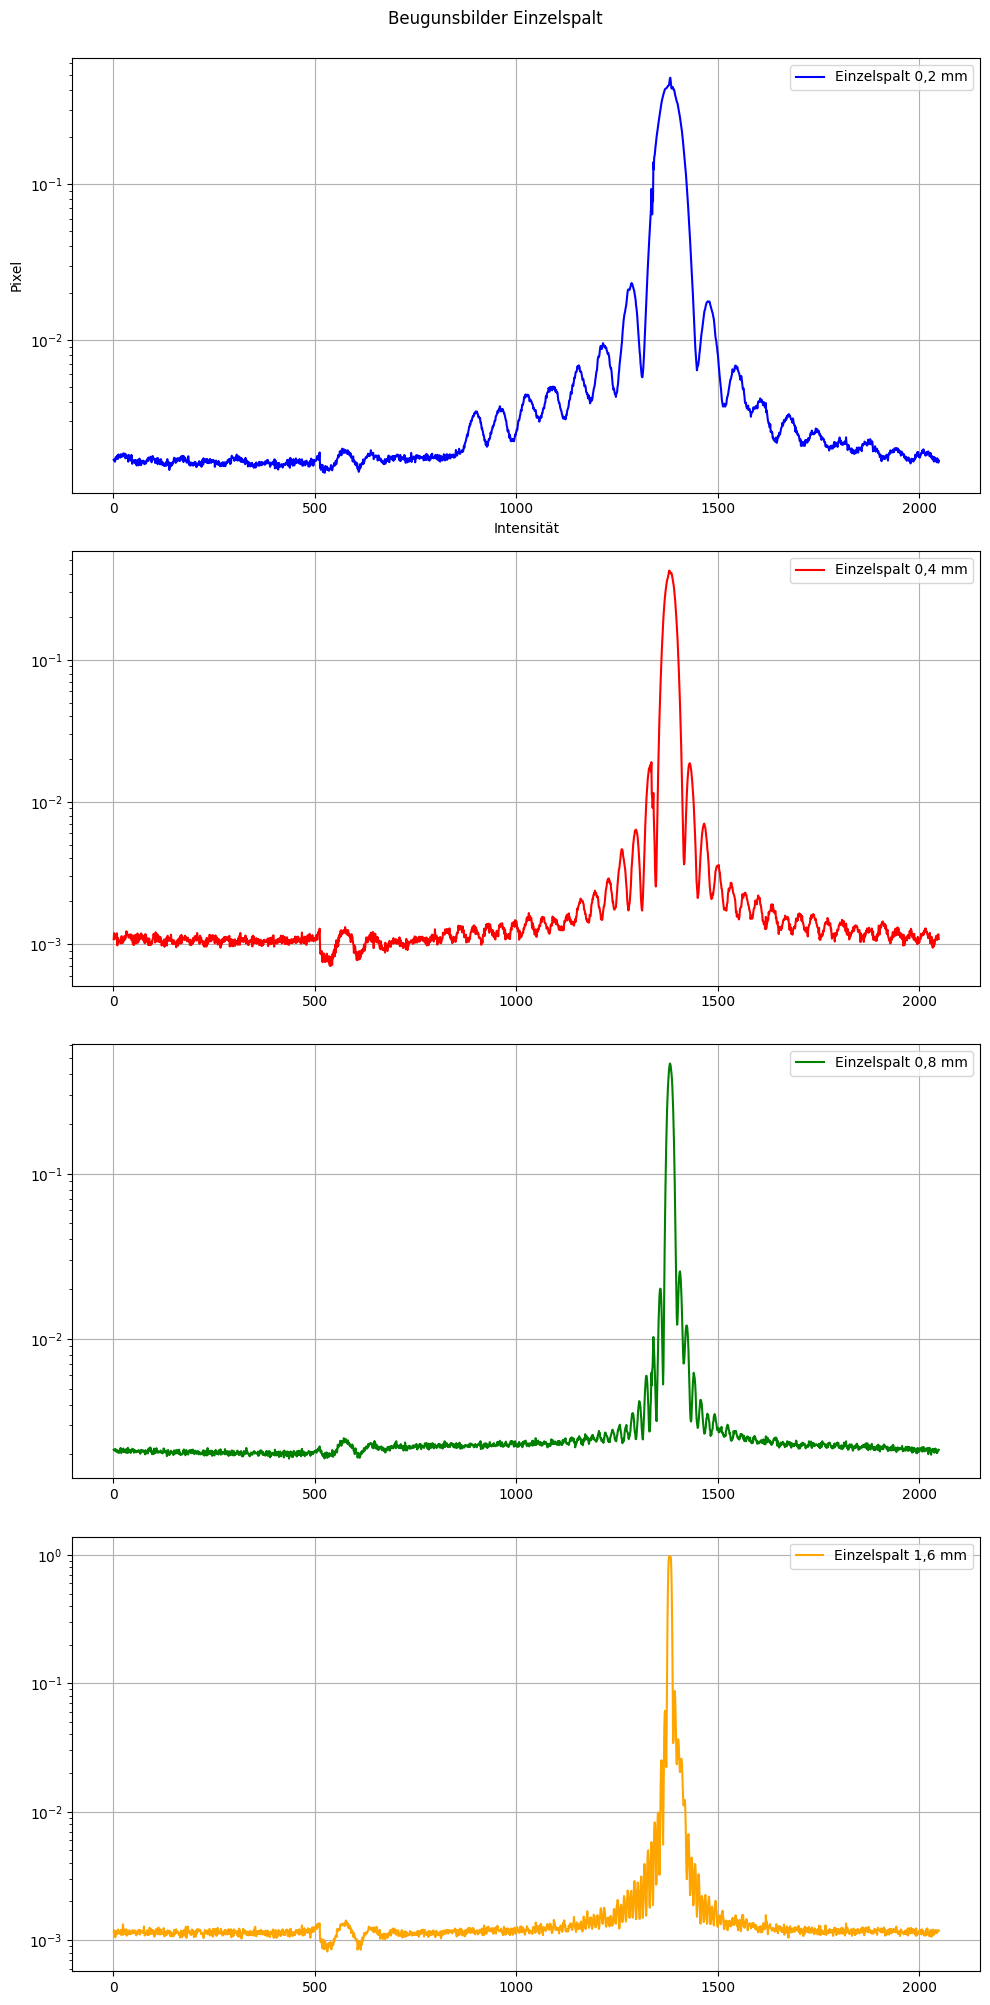

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# CSV einlesen
df = pd.read_csv("O17 Messdaten/Aufgabe 1/EinzelspaltBeugung02mm.csv")
dt = pd.read_csv("O17 Messdaten/Aufgabe 1/EinzelspaltBeugung04mm.csv")
dn = pd.read_csv("O17 Messdaten/Aufgabe 1/EinzelspaltBeugung08mm.csv")
dm = pd.read_csv("O17 Messdaten/Aufgabe 1/EinzelspaltBeugung16mm.csv")


# Plot für a_x
fig, axs = plt.subplots(4, 1, figsize=(10, 20))
fig.suptitle("Beugunsbilder Einzelspalt", y=1)

axs[0].plot(df['x'], df['y'], label="Einzelspalt 0,2 mm", color="blue")
axs[0].set_yscale("log")
axs[0].set_xlabel("Intensität")
axs[0].set_ylabel("Pixel")
axs[0].grid(True)
axs[0].legend()

axs[1].plot(dt['x'], dt['y'], label="Einzelspalt 0,4 mm", color="red")
axs[1].set_yscale("log")
axs[0].set_xlabel("Intensität")
axs[0].set_ylabel("Pixel")
axs[1].grid(True)
axs[1].legend()

axs[2].plot(dn['x'], dn['y'], label="Einzelspalt 0,8 mm", color="green")
axs[2].set_yscale("log")
axs[0].set_xlabel("Intensität")
axs[0].set_ylabel("Pixel")
axs[2].grid(True)
axs[2].legend()

axs[3].plot(dm['x'], dm['y'], label="Einzelspalt 1,6 mm", color="orange")
axs[3].set_yscale("log")
axs[0].set_xlabel("Intensität")
axs[0].set_ylabel("Pixel")
axs[3].grid(True)
axs[3].legend()

fig.tight_layout()
plt.show()

## Bestimmung der Spaltbreite mithilfe der Minima erster Ordnung

Da wir aus dem aufgenommenen Beugungsmuster auslesen können, wie viele pixel zwischen dem Maxima 0. Ordnung und den ersten Minima in beiden Richtungen liegen, können wir durch die Pixelgröße den Realabstand berechnen. Dadurch kann dann auf die Spaltbreite geschlossen werden. D. h. wir haben nehmen die pixelposition vom Maximum nullter Ordnung und die beiden ersten Minima und suche den Pixelabstand. Dann nehmen wir den Durchschnitt von den beiden und multiplizieren ihn mit der realen größe eines Pixels. Dieser war im Fall unseres Experiments 11 $\mu m$. Jetzt brauchen wir nur noch eine Formel um aus dem Abstand zum ersten Minimum die Spaltbreite zu berechnen. Dafür nutzen wir die Formel die beim Einzelspalt gilt:
$$sin(\alpha) \cdot b = n \cdot \lambda$$
Hierbei ist $n$ die Ordnungszahl des Minimums, $b$ die Spaltbreite, $\lambda$ die Wellenlänge und $\alpha$ der Winkel der n-ten Beugungsordnung. Bei unserem Aufbau sitzt die Kamera in der Brennweite von der Sammellinse und dabei gilt für kleine Winkel:
$$tan(\alpha) \approx sin(\alpha) \approx \frac{x}{f} \implies b \approx \frac{\lambda \cdot f}{x}$$
Hierbei ist x der Abstand auf der Kamera und f die Brennweite. Die Brennweite haben wir gegeben mit 308 mm und die Wellenlänge des genutzten Diodenlasers war 636 nm. Jetzt können wir die Spaltbreite mithilfe unseres Beugungsmusters berechnen. Da beim 1,6 mm Spalt das Minima erster Ordnung sehr schlecht abzulesen ist, haben wir nur die ersten 3 genutzt.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# ---------------------------------------------------
# 1) EXPERIMENTPARAMETER
# ---------------------------------------------------
lambda_ = 636e-9      # Wellenlänge in m (636 nm)
f = 0.308           # Brennweite der Linse in m -> HIER euren Wert eintragen!
pixel_size = 11e-6     # Pixelgröße in m (z.B. 7 µm)

einzelspalt_0_2 = "O17 Messdaten/Aufgabe 1/EinzelspaltBeugung02mm.csv"
einzelspalt_0_4 = "O17 Messdaten/Aufgabe 1/EinzelspaltBeugung04mm.csv"
einzelspalt_0_8 = "O17 Messdaten/Aufgabe 1/EinzelspaltBeugung08mm.csv"
einzelspalt_1_6 = "O17 Messdaten/Aufgabe 1/EinzelspaltBeugung16mm.csv"

spalte = [2, 4, 8]
# ---------------------------------------------------
# 2) Daten einlesen
# ---------------------------------------------------
df_1 = pd.read_csv(einzelspalt_0_2)
df_2 = pd.read_csv(einzelspalt_0_4)
df_3 = pd.read_csv(einzelspalt_0_8)
for i, df in enumerate([df_1, df_2, df_3], start=1):
    print(f"\n=== Auswertung für Einzelspalt-Daten {i} ===")
    x_pixels = df["x"].values          # Pixelindizes (1..N)
    I_raw = df["y"].values.astype(float)

    # ---------------------------------------------------
    # 3) Intensität leicht glätten
    # ---------------------------------------------------
    window = 7
    kernel = np.ones(window) / window
    I = np.convolve(I_raw, kernel, mode="same")

    # ---------------------------------------------------
    # 4) Hauptmaximum finden
    # ---------------------------------------------------
    peaks, _ = find_peaks(I)
    idx_max_main = peaks[np.argmax(I[peaks])]   # Index des höchsten Peaks
    x0_px = x_pixels[idx_max_main]              # Pixelposition des Hauptmaximums

    # ---------------------------------------------------
    # 5) Minima 1. Ordnung links und rechts vom Hauptmaximum
    #    -> Minima sind Peaks in -I
    # ---------------------------------------------------
    minima_idx, _ = find_peaks(-I)

    # Minima links/rechts vom Hauptmaximum
    minima_left = minima_idx[minima_idx < idx_max_main]
    minima_right = minima_idx[minima_idx > idx_max_main]

    # nächstgelegenes Minimum links/rechts = 1. Ordnung
    idx_min_left = minima_left[-1]    # größter Index < idx_max_main
    idx_min_right = minima_right[0]   # kleinster Index > idx_max_main

    x_left_px = x_pixels[idx_min_left]
    x_right_px = x_pixels[idx_min_right]

    # Pixelabstände vom Hauptmaximum
    delta_px_left = abs(x_left_px - x0_px)
    delta_px_right = abs(x_right_px - x0_px)

    # x1 als Mittelwert der beiden Seiten (sollten ideal gleich sein)
    delta_px = 0.5 * (delta_px_left + delta_px_right)
    x1_phys = delta_px * pixel_size   # Abstand 1. Minimum in Metern

    # ---------------------------------------------------
    # 6) Spaltbreite b aus Fraunhofer-Bedingung
    #    b * sin(alpha_1) = lambda,  sin(alpha_1) ≈ x1 / f
    #    -> b = lambda * f / x1
    # ---------------------------------------------------
    b = lambda_ * f / x1_phys

    print("-------------------------------------------------")
    print(f"Pixelposition Hauptmaximum         : {x0_px:.1f} px")
    print(f"Pixelposition 1. Minimum links     : {x_left_px:.1f} px")
    print(f"Pixelposition 1. Minimum rechts    : {x_right_px:.1f} px")
    print(f"Delta_px links                     : {delta_px_left:.1f} px")
    print(f"Delta_px rechts                    : {delta_px_right:.1f} px")
    print(f"gemitteltes Delta_px               : {delta_px:.1f} px")
    print(f"Abstand                            : {x1_phys:.3e} m")
    print("-------------------------------------------------")
    print(f"Spaltbreite b (nur 1. Ordnung)     : {b:.3e} m")
    print(f"                                   = {b*1e6:.2f} µm")
    print("-------------------------------------------------")
    print("Pixelabweichung: " + str(((b*1e6 - spalte[i-1]*1e2)/(pixel_size*1e6))) + " pixel")
    # ---------------------------------------------------
    # 7) Plot zur Kontrolle
    # ---------------------------------------------------
    # x-Achse um das Hauptmaximum zentrieren (in mm)
    x_rel_m = (x_pixels - x0_px) * pixel_size

    plt.figure(figsize=(8,4))
    plt.plot(x_pixels, I_raw, label="raw", color="orange")
    #plt.plot(x_rel_m * 1e3, I, label="smoothed", alpha=0.7)

    plt.axvline(x0_px, linestyle="--", label="Hauptmaximum")
    plt.axvline(x_left_px, linestyle="--", label="1. Minimum links")
    plt.axvline(x_right_px, linestyle="--", label="1. Minimum rechts")

    plt.yscale("log")
    plt.xlabel("x - x0 in mm")
    plt.ylabel("Intensität (arb. Einheiten)")
    plt.legend()
    plt.tight_layout()
    plt.show()


SyntaxError: invalid decimal literal (3183381444.py, line 88)

| Ursprüngliche Spaltbreite (b_{\text{soll}}) | Berechnete Spaltbreite (b_{\text{ist}}) | Prozentuale Abweichung |
| ------------------------------------------- | --------------------------------------- | ---------------------- |
| 0,2 mm (200 µm)                             | 258,09 µm                               | 29,05 %                |
| 0,4 mm (400 µm)                             | 501,63 µm                               | 25,41 %                |
| 0,8 mm (800 µm)                             | 962,59 µm                               | 20,32 %                |


## Fourier Transformation

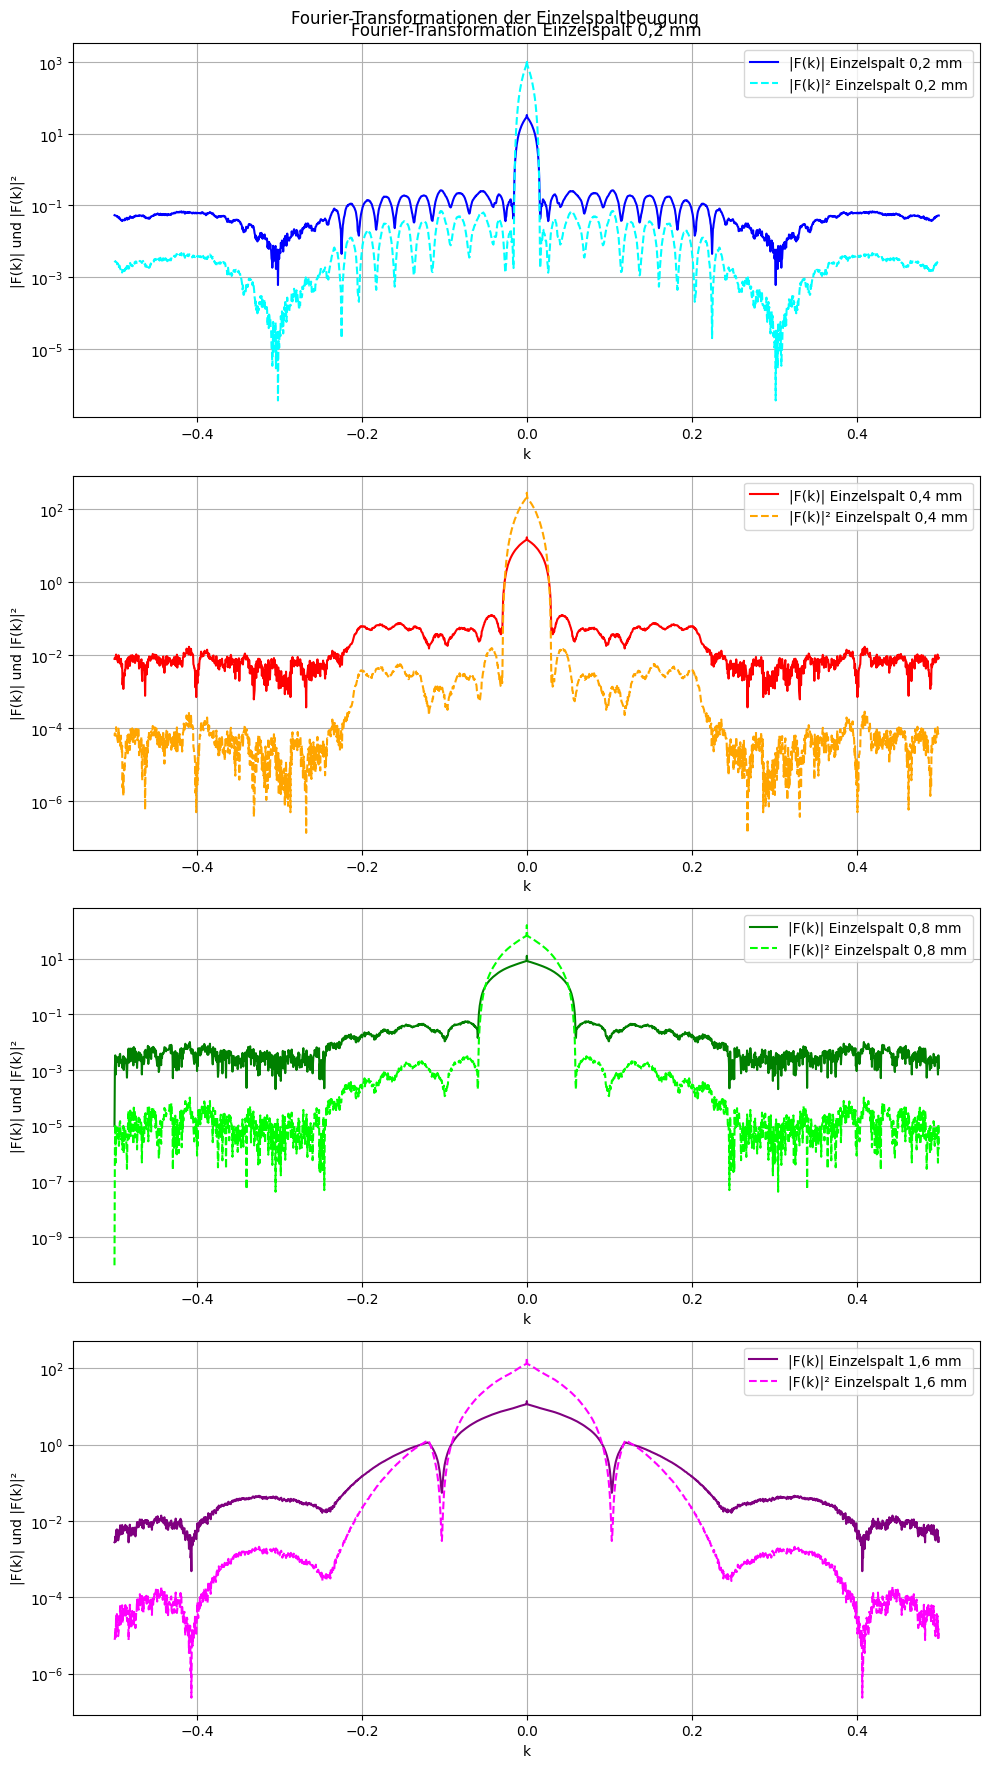

In [19]:
# Verwende bereits importierte numpy, matplotlib und die DataFrames (df, dt, dn, dm)
# (Die CSVs und Importe wurden bereits in einer früheren Zelle gemacht.)

# Fourier Transformationen mit numpy.fft (empfohlen gegenüber scipy.fftpack)
y_df = df['y'].values.astype(float)
y_dt = dt['y'].values.astype(float)
y_dn = dn['y'].values.astype(float)
y_dm = dm['y'].values.astype(float)

# Abstand in x (falls x regelmäßig, ansonsten mittlerer Abstand verwenden)
dx_df = np.mean(np.diff(df['x'].values))
dx_dt = np.mean(np.diff(dt['x'].values))
dx_dn = np.mean(np.diff(dn['x'].values))
dx_dm = np.mean(np.diff(dm['x'].values))

F_df = np.fft.fft(y_df)
F_dt = np.fft.fft(y_dt)
F_dn = np.fft.fft(y_dn)
F_dm = np.fft.fft(y_dm)

F2_df = np.abs(F_df)**2
F2_dt = np.abs(F_dt)**2
F2_dn = np.abs(F_dn)**2
F2_dm = np.abs(F_dm)**2

k_df = np.fft.fftfreq(len(y_df), d=dx_df)
k_dt = np.fft.fftfreq(len(y_dt), d=dx_dt)
k_dn = np.fft.fftfreq(len(y_dn), d=dx_dn)
k_dm = np.fft.fftfreq(len(y_dm), d=dx_dm)

# Für bessere Visualisierung: Frequenzen zentrieren (optional)
k_df_s = np.fft.fftshift(k_df)
k_dt_s = np.fft.fftshift(k_dt)
k_dn_s = np.fft.fftshift(k_dn)
k_dm_s = np.fft.fftshift(k_dm)

F_df_s = np.fft.fftshift(np.abs(F_df))
F_dt_s = np.fft.fftshift(np.abs(F_dt))
F_dn_s = np.fft.fftshift(np.abs(F_dn))
F_dm_s = np.fft.fftshift(np.abs(F_dm))

F2_df_s = np.fft.fftshift(F2_df)
F2_dt_s = np.fft.fftshift(F2_dt)
F2_dn_s = np.fft.fftshift(F2_dn)
F2_dm_s = np.fft.fftshift(F2_dm)

# Benutze anderen Namen für Achsen-Array, um keine früheren axs zu überschreiben
fig_ft, axs_ft = plt.subplots(4, 1, figsize=(10, 18))
fig_ft.suptitle("Fourier-Transformationen der Einzelspaltbeugung")

axs_ft[0].plot(k_df_s, F_df_s, label="|F(k)| Einzelspalt 0,2 mm", color="blue")
axs_ft[0].plot(k_df_s, F2_df_s, label="|F(k)|² Einzelspalt 0,2 mm", color="cyan", linestyle="--")
axs_ft[0].set_yscale("log")
axs_ft[0].set_xlabel("k")
axs_ft[0].set_ylabel("|F(k)| und |F(k)|²")
axs_ft[0].set_title("Fourier-Transformation Einzelspalt 0,2 mm")
axs_ft[0].grid(True)
axs_ft[0].legend()

axs_ft[1].plot(k_dt_s, F_dt_s, label="|F(k)| Einzelspalt 0,4 mm", color="red")
axs_ft[1].plot(k_dt_s, F2_dt_s, label="|F(k)|² Einzelspalt 0,4 mm", color="orange", linestyle="--")
axs_ft[1].set_yscale("log")
axs_ft[1].set_xlabel("k")
axs_ft[1].set_ylabel("|F(k)| und |F(k)|²")
axs_ft[1].grid(True)
axs_ft[1].legend()

axs_ft[2].plot(k_dn_s, F_dn_s, label="|F(k)| Einzelspalt 0,8 mm", color="green")
axs_ft[2].plot(k_dn_s, F2_dn_s, label="|F(k)|² Einzelspalt 0,8 mm", color="lime", linestyle="--")
axs_ft[2].set_yscale("log")
axs_ft[2].set_xlabel("k")
axs_ft[2].set_ylabel("|F(k)| und |F(k)|²")
axs_ft[2].grid(True)
axs_ft[2].legend()

axs_ft[3].plot(k_dm_s, F_dm_s, label="|F(k)| Einzelspalt 1,6 mm", color="purple")
axs_ft[3].plot(k_dm_s, F2_dm_s, label="|F(k)|² Einzelspalt 1,6 mm", color="magenta", linestyle="--")
axs_ft[3].set_yscale("log")
axs_ft[3].set_xlabel("k")
axs_ft[3].set_ylabel("|F(k)| und |F(k)|²")
axs_ft[3].grid(True)
axs_ft[3].legend()

fig_ft.tight_layout()
plt.show()

